# 문서 벡터를 이용한 추천 시스템

In [1]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from PIL import Image
from io import BytesIO
import requests
from nltk.tokenize import RegexpTokenizer
import nltk
from gensim.models import Word2Vec, KeyedVectors
from nltk.corpus import stopwords
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/09.%20Word%20Embedding/dataset/data.csv", filename="data.csv")
df = pd.read_csv("data.csv")
print('전체 문서의 수 :',len(df))

전체 문서의 수 : 2382


In [3]:
df[:3]

,Unnamed: 0.1,Desc,Unnamed: 0,author,genre,image_link,rating,title
0,0,We know that power is shifting: From West to E...,0.0,Moisés Naím,Business,https://i.gr-assets.com/images/S/compressed.ph...,3.63,The End of Power: From Boardrooms to Battlefie...
1,1,Following the success of The Accidental Billio...,1.0,Blake J. Harris,Business,https://i.gr-assets.com/images/S/compressed.ph...,3.94,"Console Wars: Sega, Nintendo, and the Battle t..."
2,2,How to tap the power of social software and ne...,2.0,Chris Brogan,Business,https://i.gr-assets.com/images/S/compressed.ph...,3.78,Trust Agents: Using the Web to Build Influence...


In [4]:
def _removeNonAscii(s):
    return "".join(i for i in s if ord(i) < 128)

def make_lower_case(text):
    return text.lower()

def remove_stop_words(text):
    text = text.split()
    stops = set(stopwords.words("english"))
    text = [w for w in text if not w in stops]
    text = " ".join(text)
    return text

def remove_html(text):
    # < : 태그의 시작, .* : .은 아무 문자 한글자, *은 바로 앞의 글자가 0개 이상 반복
    # *? : 닫는 태그를 만나는 순간 매칭 종료
    html_pattern  = re.compile('<.*?>') 
    return html_pattern.sub(r'',text)

def remove_punctuation(text):
    tokenizer = RegexpTokenizer(r'[a-zA-Z]+')
    text = tokenizer.tokenize(text)
    text = " ".join(text)
    return text

In [5]:
df['Desc'][:5]

0    We know that power is shifting: From West to E...
1    Following the success of The Accidental Billio...
2    How to tap the power of social software and ne...
3    William J. Bernstein is an American financial ...
4    Amazing book. And I joined Steve Jobs and many...
Name: Desc, dtype: str

In [6]:
df['cleaned'] = df['Desc'].apply(_removeNonAscii)
df['cleaned'] = df.cleaned.apply(make_lower_case)
df['cleaned'] = df.cleaned.apply(remove_stop_words)
df['cleaned'] = df.cleaned.apply(remove_punctuation)
df['cleaned'] = df.cleaned.apply(remove_html)

In [7]:
df['cleaned'][:5]

0    know power shifting west east north south pres...
1    following success accidental billionaires mone...
2    tap power social software networks build busin...
3    william j bernstein american financial theoris...
4    amazing book joined steve jobs many akio morit...
Name: cleaned, dtype: str

In [8]:
df['cleaned'] = df['cleaned'].replace('', np.nan)

In [9]:
df = df[df['cleaned'].notna()]
print('전체 문서의 수:',len(df))

전체 문서의 수: 2381


In [10]:
corpus = []
for words in df['cleaned']:
    corpus.append(words.split())

In [11]:
word2vec_model = Word2Vec(vector_size = 300, window=5, min_count = 2, workers = 4)
word2vec_model.build_vocab(corpus)
word2vec_model.wv.vectors_lockf = np.ones(len(word2vec_model.wv), dtype=float)
word2vec_model.wv.intersect_word2vec_format('GoogleNews-vectors-negative300.bin.gz', lockf=1.0, binary=True)
word2vec_model.train(corpus, total_examples = word2vec_model.corpus_count, epochs=15)

(3687378, 3972510)

In [12]:
def get_document_vectors(document_list):
    document_embedding_list = []
    for line in document_list:
        doc2vec = None
        count = 0
        for word in line.split():
            if word in word2vec_model.wv.index_to_key:
                count+=1
                if doc2vec is None:
                    doc2vec = word2vec_model.wv[word]
                else:
                    doc2vec = doc2vec + word2vec_model.wv[word]

        if doc2vec is not None:
            doc2vec = doc2vec / count
            document_embedding_list.append(doc2vec)

    return document_embedding_list

In [13]:
document_embedding_list = get_document_vectors(df['cleaned'])
print('문서 벡터의 수 :',len(document_embedding_list))

문서 벡터의 수 : 2381


In [14]:
cosine_similarities = cosine_similarity(document_embedding_list, document_embedding_list)
print("코사인 유사도 매트릭스의ㅣ 크기 :",cosine_similarities.shape)

코사인 유사도 매트릭스의ㅣ 크기 : (2381, 2381)


In [15]:
def recommendations(title):
    books = df[['title', 'image_link']]
    indices = pd.Series(df.index, index = df['title']).drop_duplicates()
    idx = indices[title]
    sim_scores = list(enumerate(cosine_similarities[idx]))
    sim_scores = sorted(sim_scores, key = lambda x : x[1], reverse = True)
    sim_scores = sim_scores[1:6]
    book_indices = [i[0] for i in sim_scores]
    recommend = books.iloc[book_indices].reset_index(drop=True)

    fig = plt.figure(figsize=(20,30))
    for index, row in recommend.iterrows():
        response = requests.get(row['image_link'])
        img = Image.open(BytesIO(response.content))
        # print(img)
        fig.add_subplot(1,5, index+1)
        plt.imshow(img)
        plt.title(row['title'])

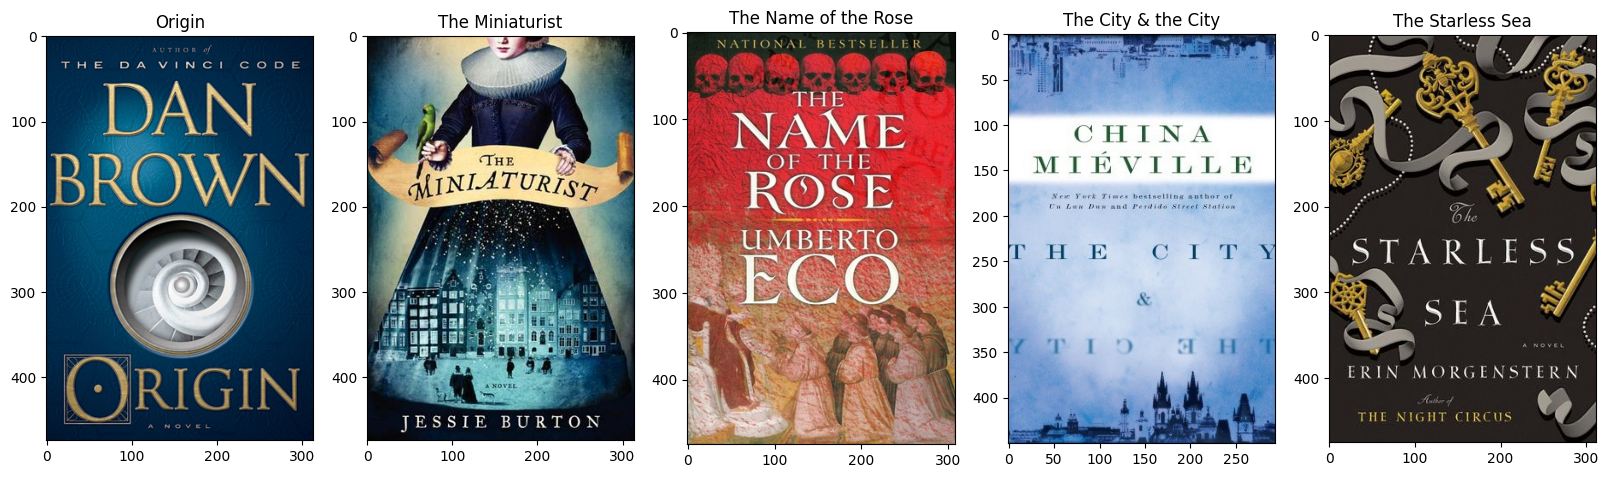

In [16]:
recommendations('The Da Vinci Code')

# RNN을 이용한 텍스트 분류: 스팸 메일 분류

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [18]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/10.%20RNN%20Text%20Classification/dataset/spam.csv", filename="spam.csv")
data = pd.read_csv('spam.csv', encoding='latin1')
print('총 샘플의 수 :',len(data))

총 샘플의 수 : 5572


In [19]:
data[:5]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [20]:
del data['Unnamed: 2']
del data['Unnamed: 3']
del data['Unnamed: 4']
data['v1'] = data['v1'].replace(['ham', 'spam'],[0,1]).astype(int)
data[:5]

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   int32
 1   v2      5572 non-null   str  
dtypes: int32(1), str(1)
memory usage: 502.6 KB


In [22]:
print('결측값 여부 :',data.isnull().values.any())

결측값 여부 : False


In [23]:
print('v2열의 유니크한 값 :',data['v2'].nunique())

v2열의 유니크한 값 : 5169


In [24]:
data.drop_duplicates(subset=['v2'], inplace=True)
print('총 샘플의 수 :',len(data))

총 샘플의 수 : 5169


<Axes: xlabel='v1'>

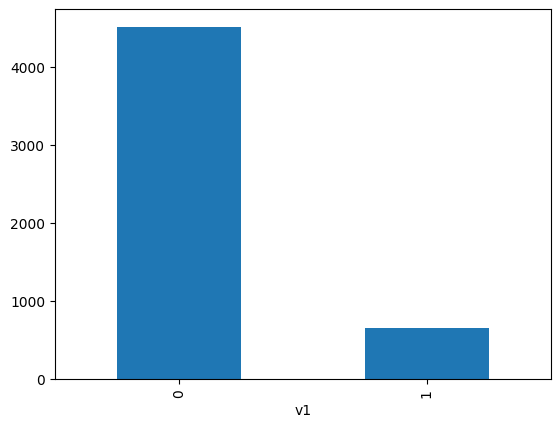

In [25]:
data['v1'].value_counts().plot(kind='bar')

In [26]:
print('정상 메일과 스팸 메일의 개수')
print(data.groupby('v1').size().reset_index(name='count'))

정상 메일과 스팸 메일의 개수
   v1  count
0   0   4516
1   1    653


In [27]:
print(f"정상 메일의 비율 = {round(data['v1'].value_counts()[0]/len(data)*100,3)}%")
print(f"스팸 메일의 비율 = {round(data['v1'].value_counts()[1]/len(data)*100,3)}%")

정상 메일의 비율 = 87.367%
스팸 메일의 비율 = 12.633%


In [28]:
X_data = data['v2']
y_data = data['v1']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=0, stratify=y_data)

In [30]:
print(f"정상 메일의 비율 = {round(y_train.value_counts()[0]/len(y_train)*100,3)}%")
print(f"스팸 메일의 비율 = {round(y_train.value_counts()[1]/len(y_train)*100,3)}%")

정상 메일의 비율 = 87.376%
스팸 메일의 비율 = 12.624%


In [31]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train_encoded = tokenizer.texts_to_sequences(X_train)
print(X_train_encoded[:5])

[[102, 1, 210, 230, 3, 17, 39], [1, 59, 8, 427, 17, 5, 137, 2, 2326], [157, 180, 12, 13, 98, 93, 47, 9, 40, 3485, 247, 8, 7, 87, 6, 80, 1312, 5, 3486, 7, 2327, 11, 660, 306, 20, 25, 467, 708, 1028, 203, 129, 193, 800, 2328, 23, 1, 144, 71, 2, 111, 78, 43, 2, 130, 11, 800, 186, 122, 1512], [1, 1154, 13, 104, 292], [222, 622, 857, 540, 623, 22, 23, 83, 10, 47, 6, 257, 32, 6, 26, 64, 936, 407]]


In [32]:
word_to_index = tokenizer.word_index
print(len(word_to_index))

7821


In [33]:
threshold = 2
total_cnt = len(word_to_index)
rare_cnt = 0
total_freq = 0
rare_freq = 0
for key, value in tokenizer.word_counts.items():
    total_freq = total_freq + value
    if (value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합(vacabulary)에서 희귀 단어의 비율:',(rare_cnt/total_cnt)*100)
print('전체 등장 빈도에서 희귀 단어 등장 빈도 비율:',(rare_freq/total_freq)*100)

등장 빈도가 1번 이하인 희귀 단어의 수: 4337
단어 집합(vacabulary)에서 희귀 단어의 비율: 55.45326684567191
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 6.65745644331875


In [34]:
vocab_size = len(word_to_index) + 1
print('단어 집합의 크기: {}'.format(vocab_size))

단어 집합의 크기: 7822


메일의 최대 길이 : 189
메일의 평균 길이 : 15.754534


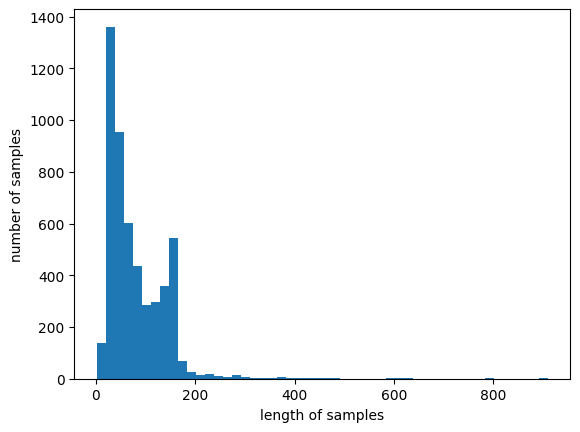

In [35]:
print('메일의 최대 길이 : %d' % max(len(sample) for sample in X_train_encoded))
print('메일의 평균 길이 : %f' % (sum(map(len,X_train_encoded))/len(X_train_encoded)))
plt.hist([len(sample) for sample in X_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [36]:
max_len = 189
X_train_padded = pad_sequences(X_train_encoded, maxlen = max_len)
print('훈련 데이터의 크기(shape):',X_train_padded.shape)

훈련 데이터의 크기(shape): (4135, 189)


In [37]:
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense
from tensorflow.keras.models import Sequential

In [38]:
embedding_dim = 32
hidden_units = 32

In [39]:
model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(SimpleRNN(hidden_units))
model.add(Dense(1, activation='sigmoid'))

In [40]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train_padded, y_train, epochs=4, batch_size=64, validation_split=0.2)

Epoch 1/4
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.9166 - loss: 0.2681 - val_acc: 0.9649 - val_loss: 0.1414
Epoch 2/4
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9782 - loss: 0.0844 - val_acc: 0.9758 - val_loss: 0.0796
Epoch 3/4
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9870 - loss: 0.0482 - val_acc: 0.9831 - val_loss: 0.0664
Epoch 4/4
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9915 - loss: 0.0296 - val_acc: 0.9770 - val_loss: 0.0676


In [41]:
X_test_encoded = tokenizer.texts_to_sequences(X_test)
X_test_padded = pad_sequences(X_test_encoded, maxlen = max_len)
print("\n 테스트 정확도: %.4f" %(model.evaluate(X_test_padded,y_test)[1]))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9797 - loss: 0.0678

 테스트 정확도: 0.9797


### GRU